
# Multimodal 100-Driver Training Notebook

This notebook keeps your **original multimodal model architecture** (image + pose + hand + face with a Transformer fusion block) and replaces only the **training data loading / handling** so it matches the **100-Driver repo** you uploaded.

## What the repo does
The uploaded repo loads data like this:

- `train.py` calls `get_train_split(args.dataset)` from `utils.py`
- `get_train_split('pic-day-cam1')` returns:
  - image root: `./data/100-driver/Day_RGB/Cam1`
  - train txt: `./data-splits/Traditional-setting/Day/Cam1/D1_train.txt`
  - val txt: `./data-splits/Traditional-setting/Day/Cam1/D1_val.txt`
- `dataset.py` then reads each split line as:

```text
<sample_id> <relative_image_path> <integer_label>
```

Example:

```text
0 C1_Drive_Safe/P006_V3_S4_0101020100.jpg 0
```

So the correct image loading logic is:

```python
img_path = IMG_ROOT / relative_path
label = int(third_column)
```

## Important note about your model
Your original model expects **four inputs**:

- image
- pose
- hand
- face

But the repo's `dataset.py` is **image-only**.  
So this notebook keeps your architecture and adds **optional landmark loading** on top of the repo's txt-based image loading.

If `LANDMARK_PATH` is missing, this notebook falls back to tiny random-noise tensors so the model still runs without changing the architecture.


In [11]:

# %%
import os
import json
import time
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image, ImageFile

from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [ ]:

# %%
# ---------------------------
# CONFIG
# ---------------------------
# Point this at the top-level dataset folder on your machine.
# Based on your screenshots, this should be the folder that contains:
#   - data-splits/
#   - possibly Day_RGB/ or data/100-driver/Day_RGB/
DATASET_ROOT = Path(r"../Datasets/100-driver")

# Split selection based on the uploaded repo's naming convention
SETTING = "Traditional-setting"   # e.g. Traditional-setting
TIME_OF_DAY = "Day"               # Day or Night
CAMERA = "Cam1"                   # Cam1 / Cam2 / Cam3 / Cam4
SPLIT_PREFIX = "D1"               # D1 for Cam1, D2 for Cam2, etc.

# Optional landmark json for your multimodal model
# Set to None if you do not have one yet.
LANDMARK_PATH = DATASET_ROOT / "driver_landmarks.json"

# Training hyperparameters (kept very close to your original notebook)
BATCH_SIZE = 128
LR = 1e-4
EPOCHS = 25
EMBED_DIM = 256
NUM_HEADS = 4
NUM_LAYERS = 2
NUM_WORKERS = 8
WEIGHT_DECAY = 1e-2
SEED = 42

# For the 100-driver repo, day datasets use these stats in utils.py
# day -> mean=[.5, .5, .5], std=[0.229, 0.224, 0.225]
# You can change these if you switch to Night.
MEAN = [0.5, 0.5, 0.5]
STD = [0.229, 0.224, 0.225]

# Candidate image roots. The notebook auto-resolves whichever one actually exists.
IMG_ROOT_CANDIDATES = [
    DATASET_ROOT / "Day" / CAMERA,
]

# Output paths
OUTPUT_DIR = Path("trained-models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "best_model_100driver_multimodal.pt"


In [13]:

# %%
# ---------------------------
# REPRODUCIBILITY
# ---------------------------
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)


In [14]:

# %%
# ---------------------------
# SPLIT / PATH HELPERS
# ---------------------------
def build_split_paths(dataset_root, setting, time_of_day, camera, split_prefix):
    split_root = (
        Path(dataset_root)
        / "data-splits"
        / "data-splits"
        / setting
        / time_of_day
        / camera
    )
    train_txt = split_root / f"{split_prefix}_train.txt"
    val_txt = split_root / f"{split_prefix}_val.txt"
    test_txt = split_root / f"{split_prefix}_test.txt"
    return split_root, train_txt, val_txt, test_txt

def parse_split_file(txt_path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 3:
                print(f"Skipping malformed line {line_no} in {txt_path}: {line!r}")
                continue

            sample_id = parts[0]
            rel_path = parts[1]
            label = int(parts[2])

            records.append({
                "sample_id": sample_id,
                "rel_path": rel_path,
                "label": label,
            })
    return records

def resolve_img_root(candidates, sample_rel_path):
    sample_rel_path = Path(sample_rel_path)
    checked = []
    for cand in candidates:
        cand = Path(cand)
        checked.append(str(cand / sample_rel_path))
        if (cand / sample_rel_path).exists():
            return cand, checked
    return None, checked

def infer_label_names(records):
    # Uses the parent folder of the relative path (e.g. C1_Drive_Safe) as a human-readable class name.
    names_by_label = defaultdict(list)
    for rec in records:
        rel_path = Path(rec["rel_path"])
        class_name = rel_path.parent.name if rel_path.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(class_name)

    label_to_name = {}
    for label, names in names_by_label.items():
        label_to_name[label] = Counter(names).most_common(1)[0][0]

    max_label = max(label_to_name.keys())
    ordered_names = [label_to_name.get(i, f"class_{i}") for i in range(max_label + 1)]
    return ordered_names, label_to_name


In [15]:

# %%
# ---------------------------
# RESOLVE SPLITS + IMAGE ROOT
# ---------------------------
split_root, TRAIN_LIST, VAL_LIST, TEST_LIST = build_split_paths(
    DATASET_ROOT, SETTING, TIME_OF_DAY, CAMERA, SPLIT_PREFIX
)

print("Split folder:", split_root)
print("TRAIN_LIST exists:", TRAIN_LIST.exists(), TRAIN_LIST)
print("VAL_LIST exists:  ", VAL_LIST.exists(), VAL_LIST)
print("TEST_LIST exists: ", TEST_LIST.exists(), TEST_LIST)

if not TRAIN_LIST.exists():
    raise FileNotFoundError(f"Train split not found: {TRAIN_LIST}")

train_records_preview = parse_split_file(TRAIN_LIST)
if len(train_records_preview) == 0:
    raise RuntimeError("Parsed zero training records from the txt split file.")

sample_rel_path = train_records_preview[0]["rel_path"]
IMG_ROOT, checked_candidates = resolve_img_root(IMG_ROOT_CANDIDATES, sample_rel_path)

print("\nSample relative path from split:", sample_rel_path)
print("\nChecked candidates:")
for path in checked_candidates:
    print(" -", path)

if IMG_ROOT is None:
    raise FileNotFoundError(
        "Could not resolve image root automatically. Update IMG_ROOT_CANDIDATES "
        "so that IMG_ROOT / sample_rel_path exists."
    )

print("\nResolved IMG_ROOT:", IMG_ROOT)
print("Sample image exists:", (IMG_ROOT / sample_rel_path).exists())
print("LANDMARK_PATH exists:", LANDMARK_PATH is not None and Path(LANDMARK_PATH).exists())


Split folder: ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1
TRAIN_LIST exists: True ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
VAL_LIST exists:   True ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
TEST_LIST exists:  True ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt

Sample relative path from split: C1_Drive_Safe/P006_V3_S4_0101020100.jpg

Checked candidates:
 - ../Datasets/100-driver/Day/Cam1/C1_Drive_Safe/P006_V3_S4_0101020100.jpg

Resolved IMG_ROOT: ../Datasets/100-driver/Day/Cam1
Sample image exists: True
LANDMARK_PATH exists: False


In [16]:

# %%
# ---------------------------
# PREVIEW LABELS / CLASS COUNT
# ---------------------------
train_records = parse_split_file(TRAIN_LIST)
val_records = parse_split_file(VAL_LIST)

all_labels = sorted({r["label"] for r in train_records} | {r["label"] for r in val_records})
NUM_CLASSES = max(all_labels) + 1
CLASS_NAMES, LABEL_TO_NAME = infer_label_names(train_records + val_records)

print("Train samples:", len(train_records))
print("Val samples:  ", len(val_records))
print("Labels found: ", all_labels)
print("NUM_CLASSES:  ", NUM_CLASSES)
print("\nFirst few class names:")
for i, name in list(enumerate(CLASS_NAMES))[:10]:
    print(f"  {i}: {name}")


Train samples: 45388
Val samples:   4334
Labels found:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
NUM_CLASSES:   22

First few class names:
  0: C1_Drive_Safe
  1: C2_Sleep
  2: C3_Yawning
  3: C4_Talk_Left
  4: C5_Talk_Right
  5: C6_Text_Left
  6: C7_Text_Right
  7: C8_Make_Up
  8: C9_Look_Left
  9: C10_Look_Right


In [17]:

# %%
# ---------------------------
# TRANSFORMS
# ---------------------------
# Kept close to the repo's dataset.py transforms, with your original validation split style.
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing()
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])


In [18]:

# %%
# ---------------------------
# MULTIMODAL DATASET
# ---------------------------
# This keeps the repo's txt-based image loading logic, but returns the extra
# pose / hand / face tensors required by your original model.
class MultiModal100DriverDataset(Dataset):
    def __init__(self, img_root, split_txt, transform=None, landmark_path=None):
        self.img_root = Path(img_root)
        self.records = parse_split_file(split_txt)
        self.transform = transform

        if landmark_path is not None and Path(landmark_path).exists():
            with open(landmark_path, "r", encoding="utf-8") as f:
                self.landmarks = json.load(f)
            print(f"Loaded landmarks for {len(self.landmarks)} keys from {landmark_path}")
        else:
            self.landmarks = {}
            print("No valid LANDMARK_PATH provided; using fallback landmark tensors.")

    def __len__(self):
        return len(self.records)

    def _get_landmarks(self, rel_path):
        # Try multiple key styles in case your landmark JSON was keyed differently.
        key_candidates = [
            rel_path,
            Path(rel_path).as_posix(),
            Path(rel_path).name,
            Path(rel_path).stem,
        ]

        feats = None
        for key in key_candidates:
            if key in self.landmarks:
                feats = self.landmarks[key]
                break

        if feats is None:
            pose = torch.randn(99) * 0.01
            hand = torch.randn(126) * 0.01
            face = torch.randn(1434) * 0.01
            return pose.float(), hand.float(), face.float()

        pose_data = feats.get("pose", [0] * 99)
        hand_data = feats.get("hand", [0] * 126)
        face_data = feats.get("face", [0] * 1434)

        def ensure_tensor(arr, size):
            if arr is None:
                arr = [0] * size
            arr = list(arr)
            if len(arr) < size:
                arr = arr + [0] * (size - len(arr))
            elif len(arr) > size:
                arr = arr[:size]

            if sum(abs(float(x)) for x in arr) == 0:
                arr = (torch.randn(size) * 0.01).tolist()

            return torch.tensor(arr, dtype=torch.float32)

        pose = ensure_tensor(pose_data, 99)
        hand = ensure_tensor(hand_data, 126)
        face = ensure_tensor(face_data, 1434)
        return pose, hand, face

    def __getitem__(self, idx):
        rec = self.records[idx]
        rel_path = rec["rel_path"]
        label = rec["label"]

        img_path = self.img_root / rel_path

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # Keeps training from crashing on a bad file, while making the failure obvious.
            print(f"Warning: failed to open {img_path}; using blank image.")
            img = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform is not None:
            img_tensor = self.transform(img)
        else:
            img_tensor = transforms.ToTensor()(img)

        pose, hand, face = self._get_landmarks(rel_path)
        return (img_tensor, pose, hand, face), label


In [19]:

# %%
# ---------------------------
# DATASETS / LOADERS
# ---------------------------
train_ds = MultiModal100DriverDataset(
    img_root=IMG_ROOT,
    split_txt=TRAIN_LIST,
    transform=train_tfms,
    landmark_path=LANDMARK_PATH if LANDMARK_PATH is not None else None,
)

val_ds = MultiModal100DriverDataset(
    img_root=IMG_ROOT,
    split_txt=VAL_LIST,
    transform=val_tfms,
    landmark_path=LANDMARK_PATH if LANDMARK_PATH is not None else None,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:  ", len(val_ds))

# Quick sanity check
(sample_img, sample_pose, sample_hand, sample_face), sample_label = train_ds[0]
print("Image shape:", tuple(sample_img.shape))
print("Pose shape: ", tuple(sample_pose.shape))
print("Hand shape: ", tuple(sample_hand.shape))
print("Face shape: ", tuple(sample_face.shape))
print("Label:      ", sample_label)


No valid LANDMARK_PATH provided; using fallback landmark tensors.
No valid LANDMARK_PATH provided; using fallback landmark tensors.
Train dataset size: 45388
Val dataset size:   4334
Image shape: (3, 224, 224)
Pose shape:  (99,)
Hand shape:  (126,)
Face shape:  (1434,)
Label:       0



## Original model architecture (kept)

This is your original architecture pattern:

- frozen `MobileNetV3-Large` image backbone
- linear projectors for image / pose / hand / face
- learned `[CLS]` token
- Transformer encoder over 5 tokens
- classifier head on the CLS output

Only `num_classes` is changed so it matches the labels found in the new txt split files.


In [20]:

# %%
# ---------------------------
# MODEL (kept from your original setup)
# ---------------------------
class DriverTransformer(nn.Module):
    def __init__(self, num_classes=10, embed_dim=256, num_heads=4, num_layers=2):
        super().__init__()

        # Stream 1: image backbone
        self.cnn = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

        # Freeze CNN backbone
        for param in self.cnn.parameters():
            param.requires_grad = False

        cnn_out = self.cnn.classifier[0].in_features
        self.cnn.classifier = nn.Identity()

        self.img_projector = nn.Sequential(
            nn.Linear(cnn_out, embed_dim),
            nn.LayerNorm(embed_dim),
        )

        # Stream 2 / 3 / 4: landmark projectors
        self.pose_proj = nn.Sequential(
            nn.Linear(99, 128), nn.ReLU(), nn.Linear(128, embed_dim)
        )
        self.hand_proj = nn.Sequential(
            nn.Linear(126, 128), nn.ReLU(), nn.Linear(128, embed_dim)
        )
        self.face_proj = nn.Sequential(
            nn.Linear(1434, 512), nn.ReLU(), nn.Linear(512, embed_dim)
        )

        # Transformer
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.2,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classifier head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, img, pose, hand, face):
        B = img.size(0)

        t_img = self.img_projector(self.cnn(img)).unsqueeze(1)
        t_pose = self.pose_proj(pose).unsqueeze(1)
        t_hand = self.hand_proj(hand).unsqueeze(1)
        t_face = self.face_proj(face).unsqueeze(1)
        t_cls = self.cls_token.expand(B, -1, -1)

        x = torch.cat((t_cls, t_img, t_pose, t_hand, t_face), dim=1)
        x = self.transformer(x)
        return self.head(x[:, 0, :])

model = DriverTransformer(
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
).to(DEVICE)

print("Model initialized.")
print("Num classes:", NUM_CLASSES)


Model initialized.
Num classes: 22


/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [21]:

# %%
# ---------------------------
# OPTIMIZER / LOSS / SCHEDULER
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

use_amp = (DEVICE.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

best_f1 = 0.0
history = []
print("AMP enabled:", use_amp)


AMP enabled: True


In [22]:

# %%
# ---------------------------
# TRAINING LOOP
# ---------------------------
print(f"Starting training for {EPOCHS} epochs...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ---- train ----
    model.train()
    train_loss = 0.0
    y_true_train, y_pred_train = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False)
    for (img, pose, hand, face), label in pbar:
        img = img.to(DEVICE, non_blocking=True)
        pose = pose.to(DEVICE, non_blocking=True)
        hand = hand.to(DEVICE, non_blocking=True)
        face = face.to(DEVICE, non_blocking=True)
        label = label.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(img, pose, hand, face)
            loss = criterion(logits, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * img.size(0)
        preds = logits.argmax(dim=1)

        y_true_train.extend(label.detach().cpu().numpy())
        y_pred_train.extend(preds.detach().cpu().numpy())

    train_loss /= len(train_loader.dataset)
    train_f1 = f1_score(y_true_train, y_pred_train, average="macro")

    # ---- val ----
    model.eval()
    val_loss = 0.0
    y_true_val, y_pred_val = [], []

    with torch.no_grad():
        for (img, pose, hand, face), label in tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False):
            img = img.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)
            hand = hand.to(DEVICE, non_blocking=True)
            face = face.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE, non_blocking=True)

            logits = model(img, pose, hand, face)
            loss = criterion(logits, label)

            val_loss += loss.item() * img.size(0)
            preds = logits.argmax(dim=1)

            y_true_val.extend(label.detach().cpu().numpy())
            y_pred_val.extend(preds.detach().cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
    scheduler.step(val_f1)

    dt = time.time() - t0
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} val_f1={val_f1:.4f} | "
        f"lr={current_lr:.2e} | {dt:.1f}s"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_f1": val_f1,
        "lr": current_lr,
    })

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  --> Saved best model to {BEST_MODEL_PATH}")

print(f"Training complete. Best val F1: {best_f1:.4f}")


Starting training for 25 epochs...


Epoch 01 | train_loss=2.8650 train_f1=0.1247 | val_loss=2.5694 val_f1=0.1698 | lr=1.00e-04 | 84.9s
  --> Saved best model to trained-models/best_model_100driver_multimodal.pt


Epoch 02 | train_loss=2.4060 train_f1=0.2606 | val_loss=2.3877 val_f1=0.2394 | lr=1.00e-04 | 75.4s
  --> Saved best model to trained-models/best_model_100driver_multimodal.pt


Epoch 03 | train_loss=2.1822 train_f1=0.3291 | val_loss=2.4498 val_f1=0.2606 | lr=1.00e-04 | 77.5s
  --> Saved best model to trained-models/best_model_100driver_multimodal.pt


Epoch 04 | train_loss=2.0459 train_f1=0.3756 | val_loss=2.4319 val_f1=0.2665 | lr=1.00e-04 | 75.4s
  --> Saved best model to trained-models/best_model_100driver_multimodal.pt


...

Epoch 21 | train_loss=1.2704 train_f1=0.6110 | val_loss=3.1930 val_f1=0.2753 | lr=6.25e-06 | 74.8s


Epoch 22 | train_loss=1.2593 train_f1=0.6118 | val_loss=3.2235 val_f1=0.2701 | lr=6.25e-06 | 75.7s


Epoch 23 | train_loss=1.2641 train_f1=0.6121 | val_loss=3.2390 val_f1=0.2678 | lr=3.13e-06 | 75.7s


Epoch 24 | train_loss=1.2589 train_f1=0.6146 | val_loss=3.1555 val_f1=0.2731 | lr=3.13e-06 | 75.4s


Epoch 25 | train_loss=1.2448 train_f1=0.6154 | val_loss=3.2098 val_f1=0.2699 | lr=3.13e-06 | 76.0s
Training complete. Best val F1: 0.2887


,epoch,train_loss,train_f1,val_loss,val_f1,lr
20,21,1.270377,0.610993,3.193020,0.275325,0.000006
21,22,1.259328,0.611833,3.223517,0.270067,0.000006
22,23,1.264087,0.612061,3.238977,0.267788,0.000003
23,24,1.258893,0.614588,3.155457,0.273073,0.000003
24,25,1.244771,0.615396,3.209765,0.269879,0.000003


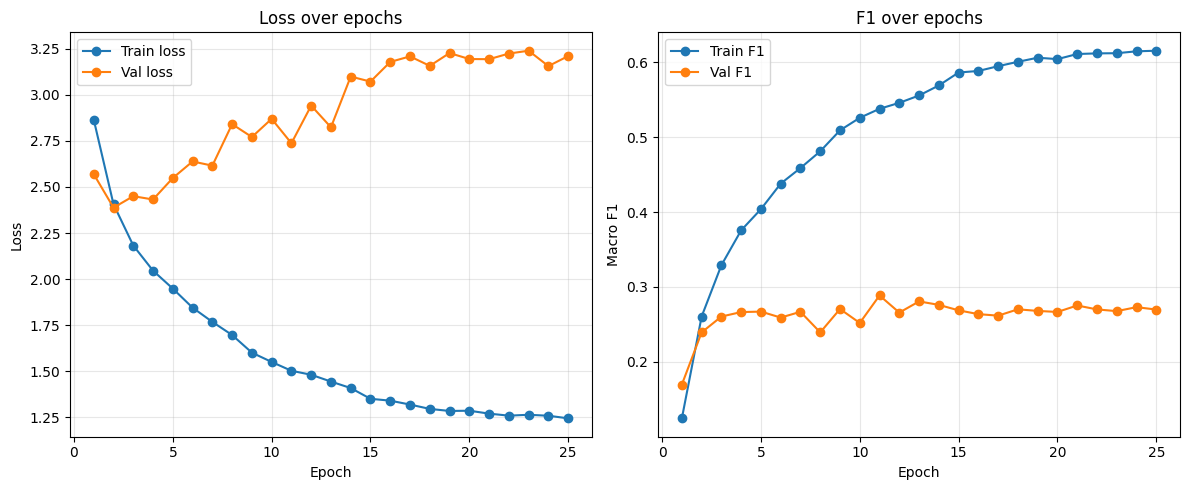

In [23]:

# %%
# ---------------------------
# HISTORY PLOTS
# ---------------------------
history_df = pd.DataFrame(history)
display(history_df.tail())

if not history_df.empty:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["epoch"], history_df["train_f1"], marker="o", label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("F1 over epochs")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No history found. Run the training cell first.")


/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Evaluating best model: 100%|██████████| 34/34 [00:08<00:00,  3.87it/s]

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

           C1_Drive_Safe     0.0791    0.1652    0.1069       224
                C2_Sleep     0.0719    0.0744    0.0731       309
              C3_Yawning     0.1887    0.1093    0.1384       183
            C4_Talk_Left     0.5037    0.2605    0.3434       261
           C5_Talk_Right     0.1728    0.1935    0.1826       217
            C6_Text_Left     0.1303    0.2552    0.1725       145
           C7_Text_Right     0.2412    0.2423    0.2418       227
              C8_Make_Up     0.3103    0.7052    0.4310       268
            C9_Look_Left     0.0920    0.0950    0.0935       242
          C10_Look_Right     0.2763    0.2937    0.2847       143
             C11_Look_Up     0.6000    0.7808    0.6786       146
           C12_Look_Down     0.6145    0.5025    0.5528       203
          C13_Smoke_Left     0.6774    0.4268    0.5237       246
         C14_Smoke_Right     0.2557    0.2284    0.24

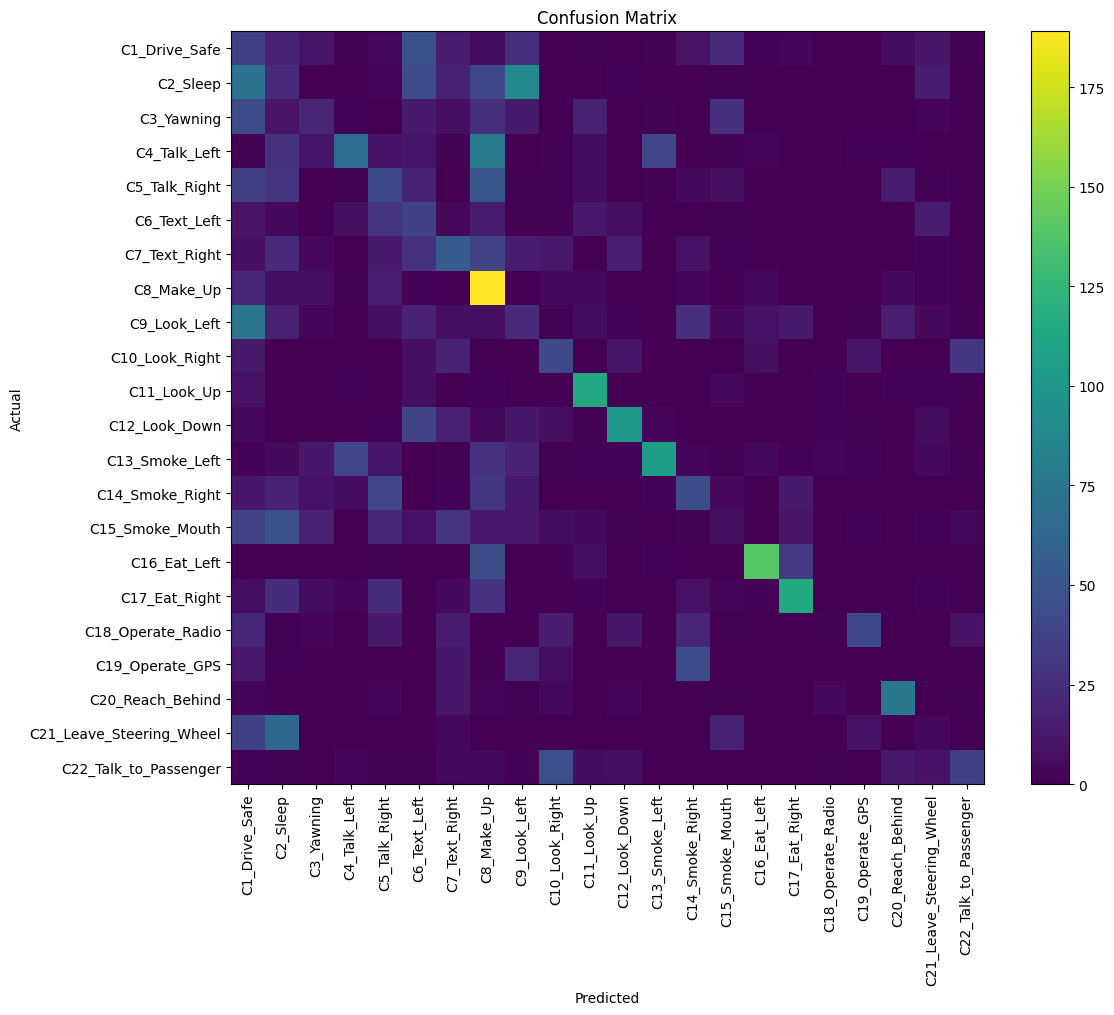

In [24]:

# %%
# ---------------------------
# LOAD BEST MODEL + DETAILED EVALUATION
# ---------------------------
eval_model = DriverTransformer(
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
).to(DEVICE)

eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
eval_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for (img, pose, hand, face), label in tqdm(val_loader, desc="Evaluating best model"):
        img = img.to(DEVICE, non_blocking=True)
        pose = pose.to(DEVICE, non_blocking=True)
        hand = hand.to(DEVICE, non_blocking=True)
        face = face.to(DEVICE, non_blocking=True)
        label = label.to(DEVICE, non_blocking=True)

        logits = eval_model(img, pose, hand, face)
        preds = logits.argmax(dim=1)

        y_true.extend(label.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=90)
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



## Optional notes

- If you switch to a **Night** split, update:
  - `TIME_OF_DAY = "Night"`
  - `MEAN` / `STD` to the repo's night values from `utils.py`
- If your landmark JSON uses a different key style, update `_get_landmarks()` so it matches your JSON exactly.
- If you want this to run **image-only**, the model would need to be changed.  
  This notebook does **not** do that, because you asked to keep your original model setup.
